In [1]:
# ======================
# A.0.1 Carga de ENO dataset
# ======================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
RUTA_ENO = "/content/drive/MyDrive/Preparación de datos/20241218_base_eno_final.csv"

#Comunas
MY_COMUNAS = [13104, 13109, 13126]

#Columnas solicitadas
eno_cols = [
    "ENO",
    "anho_notificacion",
    "region",
    "codigo_comuna_residencia",
    "nacionalidad",
    "sexo",
    "grupo_edad",
    "nombre_instruccion",
    "cie_10_diagnostico",
    "diagnostico",
    "pais_contagio"
]

#Carga del dataset
eno = pd.read_csv(
    RUTA_ENO,
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

#Salida
print("eno.shape:")
print(eno.shape)

print("\n" + "=" * 80 + "\n")

print("eno.info():")
eno.info()

Mounted at /content/drive
eno.shape:
(333300, 11)


eno.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


In [2]:
# A.0.2 Filtrado por comunas
# Convertir comunas a string
my_comunas_str = [str(c) for c in MY_COMUNAS]

# Filtrar dataset
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)]

# Reportar cantidad de filas en las comunas
print(f"Rows in my comunas: {len(eno_com):,}")

print("\n" + "=" * 80 + "\n")

# Contar filas anonimizadas del dataset
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()

print(f"Rows with codigo_comuna_residencia == '*****': {anon_count:,}")
print(f"Percentage anonymized: {anon_count / len(eno):.2%}")

Rows in my comunas: 3,209


Rows with codigo_comuna_residencia == '*****': 148,217
Percentage anonymized: 44.47%


In [3]:
# A.0.3 Distincion por nacionalidad
# Distribución de nacionalidad en tus comunas
nat_counts = eno_com["nacionalidad"].value_counts(dropna=False)

print("Distribution of 'nacionalidad' in filtered data:")
print(nat_counts)

print("\n" + "=" * 80 + "\n")

# Calcular cuántas filas son "Desconocido"
desconocido_count = (eno_com["nacionalidad"] == "Desconocido").sum()

print(f"Rows with nacionalidad == 'Desconocido': {desconocido_count:,}")
print(f"Percentage: {desconocido_count / len(eno_com):.2%}")

print("\n" + "=" * 80 + "\n")

# Crear dataset SIN desconocidos
eno_com_clean = eno_com[eno_com["nacionalidad"] != "Desconocido"]

print(f"Rows after dropping 'Desconocido': {len(eno_com_clean):,}")
print(f"Rows dropped: {desconocido_count:,}")

Distribution of 'nacionalidad' in filtered data:
nacionalidad
Chile          1540
Desconocido     901
Extranjero      768
Name: count, dtype: int64


Rows with nacionalidad == 'Desconocido': 901
Percentage: 28.08%


Rows after dropping 'Desconocido': 2,308
Rows dropped: 901


In [4]:
# A.0.4 Reporte de tiempo
# Rango de años
min_year = eno_com["anho_notificacion"].min()
max_year = eno_com["anho_notificacion"].max()

print(f"Time span: {min_year} - {max_year}")

print("\n" + "=" * 80 + "\n")

# Notificaciones por año (tabla)
notifications_per_year = (
    eno_com
    .groupby("anho_notificacion")
    .size()
    .reset_index(name="count")
    .sort_values("anho_notificacion")
)

print("Notifications per year:")
print(notifications_per_year)

Time span: 2007 - 2024


Notifications per year:
    anho_notificacion  count
0                2007    111
1                2008    108
2                2009     98
3                2010     89
4                2011    136
5                2012    132
6                2013    111
7                2014    142
8                2015    123
9                2016    123
10               2017    169
11               2018    262
12               2019    316
13               2020    188
14               2021    171
15               2022    206
16               2023    482
17               2024    242


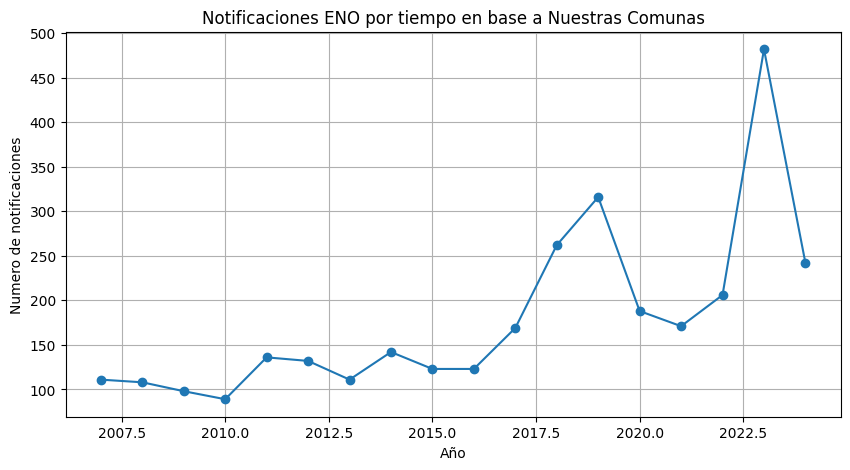

In [52]:
# A.1.1 Tendencia
import matplotlib.pyplot as plt

# Recalcular para asegurar consistencia
notifications_per_year = (
    eno_com
    .groupby("anho_notificacion")
    .size()
    .reset_index(name="count")
    .sort_values("anho_notificacion")
)

plt.figure(figsize=(10, 5))
plt.plot(
    notifications_per_year["anho_notificacion"],
    notifications_per_year["count"],
    marker='o'
)

plt.title("Notificaciones ENO por tiempo en base a Nuestras Comunas")
plt.xlabel("Año")
plt.ylabel("Numero de notificaciones")
plt.grid(True)

plt.show()

Se puede observar un peak en el numero de notificaciones en el año 2023, ademas de una leve tendencia al alta con el pasar de los años en las columnas seleccionadas

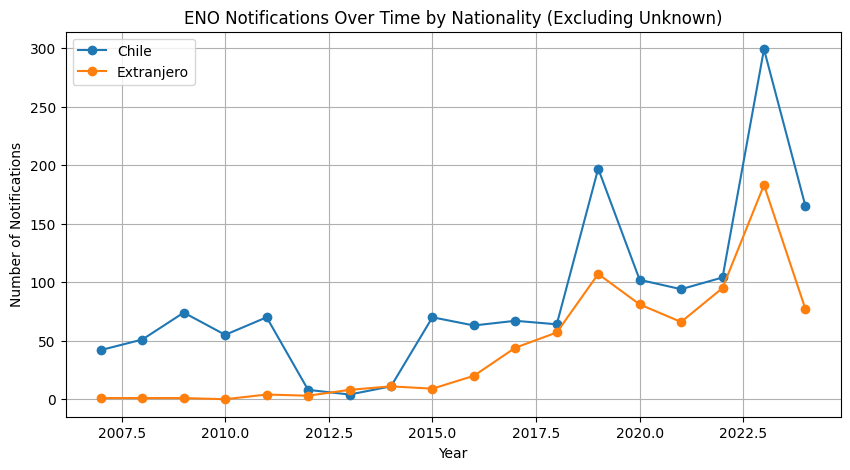

In [6]:
#A.1.2 Tendencia por nacionalidad
# ======================

import matplotlib.pyplot as plt

# Excluir "Desconocido"
eno_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"]

# Agrupar por año y nacionalidad
trend_nat = (
    eno_nat
    .groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

# Pivotear para tener columnas separadas
trend_pivot = trend_nat.pivot(
    index="anho_notificacion",
    columns="nacionalidad",
    values="count"
).fillna(0)

# Plot
plt.figure(figsize=(10, 5))

for col in trend_pivot.columns:
    plt.plot(
        trend_pivot.index,
        trend_pivot[col],
        marker='o',
        label=col
    )

plt.title("ENO Notifications Over Time by Nationality (Excluding Unknown)")
plt.xlabel("Year")
plt.ylabel("Number of Notifications")
plt.legend()
plt.grid(True)

plt.show()

Al revisar los grupos de chilenos y extranjeros, se ve que mantienen un comportamiento parecido, con las mismas subidas y tendencias a excepcion de los años 2012, 2013 y 2014


Top 10 enfermedades:
ENO
Hepatitis B                         26
Hepatitis C                         36
Enfermedad meningocócica            38
Infección gonocócica                43
Fiebre Tifoidea y Paratifoidea      52
Chagas                             140
Coqueluche                         243
Sifilis                            325
Parotiditis                        610
VIH                               1590
Name: count, dtype: int64


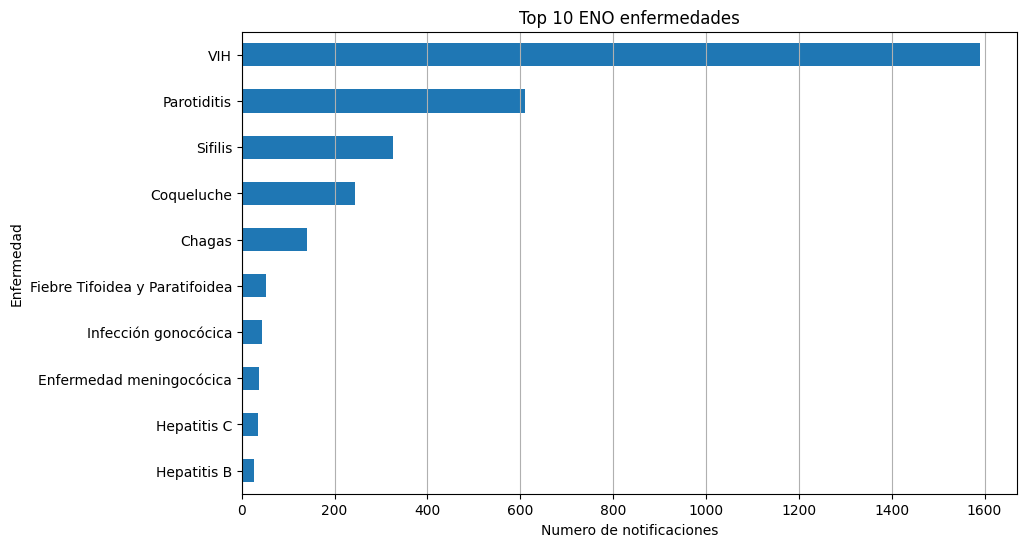

In [53]:
# ======================
# A.2.1 Top diseases overall
# ======================

import matplotlib.pyplot as plt

# Top 10 enfermedades (columna ENO)
top_diseases = (
    eno_com["ENO"]
    .value_counts()
    .head(10)
    .sort_values()  # para gráfico horizontal ordenado
)

print("Top 10 enfermedades:")
print(top_diseases)

# Plot
plt.figure(figsize=(10, 6))
top_diseases.plot(kind="barh")

plt.title("Top 10 ENO enfermedades")
plt.xlabel("Numero de notificaciones")
plt.ylabel("Enfermedad")

plt.grid(axis='x')

plt.show()

En el caso de las comunas que se utilizan para este trabajo se observa que el mayor numero de notificaciones es el VIH, seguido de la parotidis y la sifilis

Shares by nationality:
nacionalidad     Chile  Extranjero
ENO                               
Chagas        0.833333    0.166667
Coqueluche    1.000000    0.000000
Parotiditis   0.877049    0.122951
Sifilis       0.606154    0.393846
VIH           0.604467    0.395533


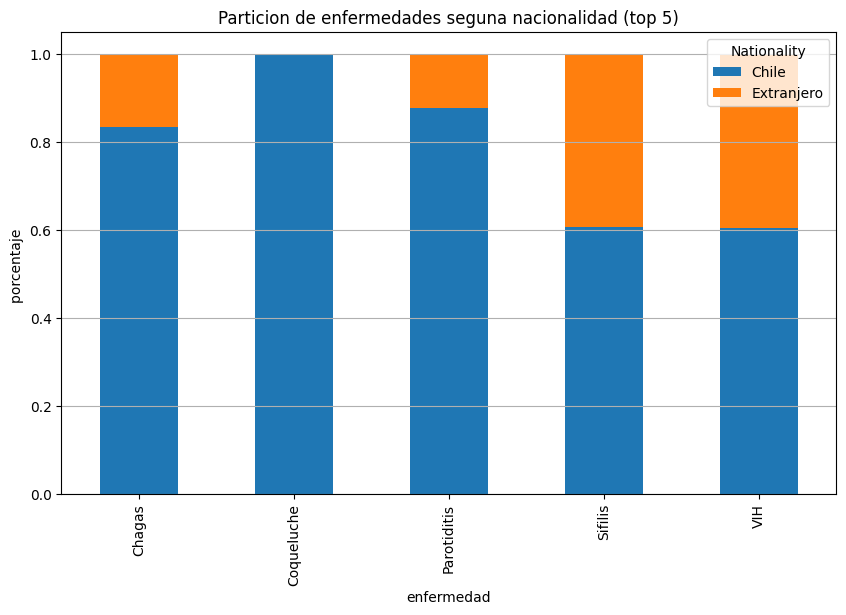

In [54]:
# ======================
# A.2.2 Disease profiles by nationality
# ======================

import matplotlib.pyplot as plt

# Usar dataset sin "Desconocido"
eno_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"]

# Top 5 enfermedades
top5 = eno_com["ENO"].value_counts().head(5).index

# Filtrar solo esas enfermedades
eno_top5 = eno_nat[eno_nat["ENO"].isin(top5)]

# Agrupar
disease_nat = (
    eno_top5
    .groupby(["ENO", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

# Pivotear
disease_pivot = disease_nat.pivot(
    index="ENO",
    columns="nacionalidad",
    values="count"
).fillna(0)

# Convertir a proporciones (shares)
disease_share = disease_pivot.div(disease_pivot.sum(axis=1), axis=0)

print("Shares by nationality:")
print(disease_share)

# Plot (stacked bar)
disease_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Particion de enfermedades seguna nacionalidad (top 5)")
plt.ylabel("porcentaje ")
plt.xlabel("enfermedad")
plt.legend(title="Nationality")
plt.grid(axis='y')

plt.show()

Según este grafico se puede observar que los chilenos son los que se llevan la mayoría de la participación para el top 5 de enfermedades en nuestras comunas.

Top disease: VIH

Age distribution:
nacionalidad  Chile  Extranjero
grupo_edad                     
***             3.0         5.0
00-04           1.0         0.0
05-09           1.0         1.0
10-14           3.0         1.0
15-19          29.0         6.0
20-24         128.0        71.0
25-29         149.0       123.0
30-34         136.0       140.0
35-39         105.0        95.0
40-44          61.0        57.0
45-49          85.0        19.0
50-54          47.0        17.0
55-59          47.0        10.0
60-64          16.0         4.0
65-69          15.0         0.0
70-74          10.0         0.0
75-79           1.0         0.0
80y+            2.0         0.0


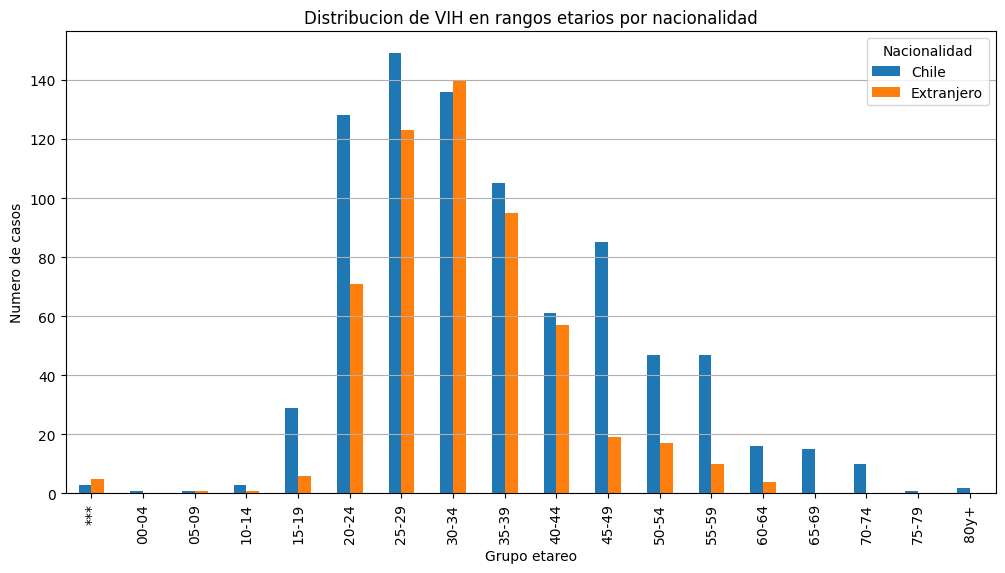

In [55]:
# ======================
# A.2.3 Age-group distribution for the top disease
# ======================

import matplotlib.pyplot as plt

# Definir enfermedad principal
top_disease = eno_com["ENO"].value_counts().idxmax()

print(f"Top disease: {top_disease}")

# Usar dataset sin "Desconocido"
eno_nat = eno_com[eno_com["nacionalidad"] != "Desconocido"]

# Filtrar solo la enfermedad principal
eno_top = eno_nat[eno_nat["ENO"] == top_disease]

# Agrupar por edad y nacionalidad
age_nat = (
    eno_top
    .groupby(["grupo_edad", "nacionalidad"])
    .size()
    .reset_index(name="count")
)

# Pivotear
age_pivot = age_nat.pivot(
    index="grupo_edad",
    columns="nacionalidad",
    values="count"
).fillna(0)

# Ordenar grupos de edad (opcional pero recomendable)
age_pivot = age_pivot.sort_index()

print("\nAge distribution:")
print(age_pivot)

# Plot
age_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(f"Distribucion de {top_disease} en rangos etarios por nacionalidad")
plt.xlabel("Grupo etareo")
plt.ylabel("Numero de casos")
plt.legend(title="Nacionalidad")
plt.grid(axis='y')

plt.show()

Al ver las distribuciones por edad se observan campanas con los rangos de 25-29 y 30-34 siendo el mayor numero de observaciones de chile y extranjeros respectivamente

Notifications by comuna:
  codigo_comuna_residencia  count
1                    13109    714
0                    13104   1134
2                    13126   1361


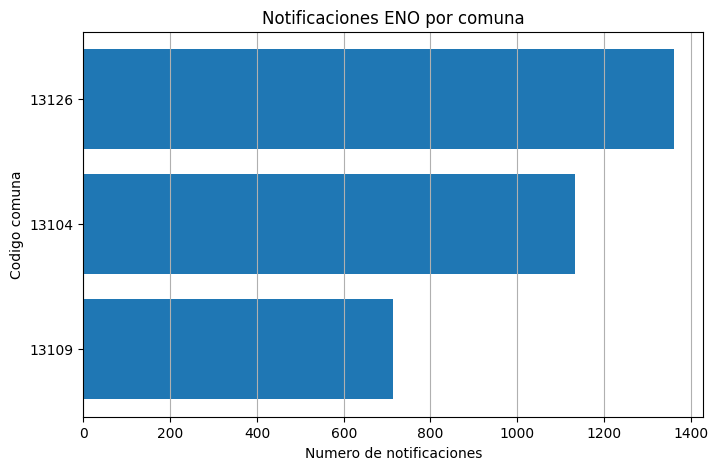

In [56]:
# ======================
# A.3.1 Notification counts by comuna
# ======================

import matplotlib.pyplot as plt

# Conteo total por comuna
comuna_counts = (
    eno_com
    .groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="count")
    .sort_values("count")
)

print("Notifications by comuna:")
print(comuna_counts)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(
    comuna_counts["codigo_comuna_residencia"],
    comuna_counts["count"]
)

plt.title("Notificaciones ENO por comuna")
plt.xlabel("Numero de notificaciones")
plt.ylabel("Codigo comuna")

plt.grid(axis='x')

plt.show()

Aun teniendo las comunas por codigo, podemos ver que 13126 es la que mantiene un mayor numero de notificaciones totales (historico)

In [11]:
# ======================
# A.4 Comuna-Level ENO Summary Table
# ======================

import os
import pandas as pd

# Rutas
RUTA_TAREA1 = "/content/drive/MyDrive/Tarea1_Censo/output/tarea1_comuna_summary.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Preparación de datos/output"
OUTPUT_ENO = f"{OUTPUT_DIR}/tarea2_eno_summary.csv"

# Crear carpeta output si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar resumen de Tarea 1
t1 = pd.read_csv(RUTA_TAREA1)

# Verificar columnas mínimas necesarias
required_cols = ["codigo_comuna", "nombre_comuna", "pop_total"]
missing_cols = [c for c in required_cols if c not in t1.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en Tarea 1: {missing_cols}")

# Preparar columnas para merge
t1_use = t1[required_cols].copy()
t1_use["codigo_comuna"] = t1_use["codigo_comuna"].astype(str)

# Top 3 enfermedades por comuna
top3_by_comuna = (
    eno_com
    .groupby("codigo_comuna_residencia")["ENO"]
    .apply(lambda s: ", ".join(s.value_counts().head(3).index.tolist()))
    .reset_index(name="eno_top3_diseases")
)

# Resumen ENO por comuna
eno_summary = (
    eno_com
    .groupby("codigo_comuna_residencia")
    .agg(
        eno_total=("ENO", "size"),
        eno_chilean=("nacionalidad", lambda s: (s == "Chile").sum()),
        eno_foreign=("nacionalidad", lambda s: (s == "Extranjero").sum()),
        eno_desconocido=("nacionalidad", lambda s: (s == "Desconocido").sum())
    )
    .reset_index()
    .rename(columns={"codigo_comuna_residencia": "codigo_comuna"})
)

# Agregar top 3 enfermedades
eno_summary = eno_summary.merge(
    top3_by_comuna.rename(columns={"codigo_comuna_residencia": "codigo_comuna"}),
    on="codigo_comuna",
    how="left"
)

# Agregar nombre comuna y población desde Tarea 1
eno_summary = eno_summary.merge(
    t1_use,
    on="codigo_comuna",
    how="left"
)

# Calcular tasa por 10.000 habitantes
eno_summary["eno_rate_per_10k"] = (eno_summary["eno_total"] / eno_summary["pop_total"]) * 10000

# Reordenar columnas finales
eno_summary = eno_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "eno_chilean",
        "eno_foreign",
        "eno_desconocido",
        "eno_top3_diseases",
        "eno_rate_per_10k"
    ]
]

# Mostrar tabla
print("ENO summary table:")
print(eno_summary)

print("\n" + "=" * 80 + "\n")

# Guardar CSV
eno_summary.to_csv(OUTPUT_ENO, index=False)
print(f"Archivo guardado en: {OUTPUT_ENO}")

ENO summary table:
  codigo_comuna  nombre_comuna  eno_total  eno_chilean  eno_foreign  \
0         13104       Conchalí       1134          635          188   
1         13109    La Cisterna        714          333          149   
2         13126  Quinta Normal       1361          572          431   

   eno_desconocido             eno_top3_diseases  eno_rate_per_10k  
0              311     VIH, Parotiditis, Sifilis         93.266550  
1              232  VIH, Parotiditis, Coqueluche         69.214886  
2              358     VIH, Parotiditis, Sifilis        105.217586  


Archivo guardado en: /content/drive/MyDrive/Preparación de datos/output/tarea2_eno_summary.csv


In [12]:
# ======================
# B.0.1 Load GRD files for 2022–2024 (FINAL FIX)
# ======================

import zipfile
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Preparación de datos"

zip_txt_map = {
    2022: ("GRD_PUBLICO_EXTERNO_2022.txt", "utf-16"),
    2023: ("GRD_PUBLICO_2023.txt", "utf-16"),
    2024: ("GRD_PUBLICO_2024.txt", "latin-1")
}

grd_cols = [
    "COMUNA",
    "NACIONALIDAD",
    "SEXO",
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA",
    "TIPOALTA",
    "DIAGNOSTICO1",
    "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD",
    "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD",
    "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

frames = []

for year in [2022, 2023, 2024]:
    txtname, encoding = zip_txt_map[year]
    zippath = f"{BASE_PATH}/GRD_PUBLICO_{year}.zip"

    print(f"\nCargando {year}...")

    with zipfile.ZipFile(zippath) as z:
        with z.open(txtname) as f:
            df_year = pd.read_csv(
                f,
                sep="|",
                encoding=encoding,
                engine="python",
                on_bad_lines="warn"
            )

    # Limpiar columnas
    df_year.columns = df_year.columns.str.strip()

    # Filtrar columnas necesarias
    df_year = df_year[grd_cols].copy()

    df_year["year"] = year

    print(f"Filas cargadas {year}: {len(df_year):,}")
    frames.append(df_year)

# Concatenar
grd = pd.concat(frames, ignore_index=True)

# Outputs requeridos
print("\n" + "="*80)
print(f"Total discharges (3 years): {len(grd):,}")

print("\n" + "="*80)
print("grd.shape:")
print(grd.shape)

print("\n" + "="*80)
print("grd.info():")
grd.info()


Cargando 2022...


/tmp/ipykernel_3403/819019549.py:43: ParserWarning: Skipping line 120127: Expected 129 fields in line 120127, saw 130

  df_year = pd.read_csv(


Filas cargadas 2022: 932,839

Cargando 2023...
Filas cargadas 2023: 1,039,587

Cargando 2024...
Filas cargadas 2024: 1,085,813

Total discharges (3 years): 3,058,239

grd.shape:
(3058239, 15)

grd.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3058239 entries, 0 to 3058238
Data columns (total 15 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   COMUNA               object
 1   NACIONALIDAD         object
 2   SEXO                 object
 3   FECHA_NACIMIENTO     object
 4   FECHA_INGRESO        object
 5   FECHAALTA            object
 6   TIPOALTA             object
 7   DIAGNOSTICO1         object
 8   DIAGNOSTICO2         object
 9   IR_29301_SEVERIDAD   object
 10  IR_29301_MORTALIDAD  object
 11  IR_29301_COD_GRD     object
 12  TIPO_INGRESO         object
 13  ESPECIALIDAD_MEDICA  object
 14  year                 int64 
dtypes: int64(1), object(14)
memory usage: 350.0+ MB


In [13]:
# ======================
# B.0.2 Filter to your comunas
# ======================

import pandas as pd

# Mapeo código -> nombre comuna en mayúsculas, como pide GRD
comuna_code_to_name = {
    13104: "CONCHALÍ",
    13109: "LA CISTERNA",
    13126: "QUINTA NORMAL"
}

# Lista de nombres de tus comunas en formato GRD
my_comuna_names = list(comuna_code_to_name.values())

print("My comuna names for GRD filter:")
print(my_comuna_names)

print("\n" + "=" * 80 + "\n")

# Filtrar GRD a tus comunas
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()

print(f"Discharges in my comunas: {len(grd_com):,}")

print("\n" + "=" * 80 + "\n")

# Reportar discharges por año
discharges_per_year = (
    grd_com
    .groupby("year")
    .size()
    .reset_index(name="count")
    .sort_values("year")
)

print("Discharges per year in my comunas:")
print(discharges_per_year)

My comuna names for GRD filter:
['CONCHALÍ', 'LA CISTERNA', 'QUINTA NORMAL']


Discharges in my comunas: 49,341


Discharges per year in my comunas:
   year  count
0  2022  15820
1  2023  16854
2  2024  16667


In [14]:
# ======================
# B.0.3 Compute length of stay
# ======================

import pandas as pd

# Convertir fechas
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors="coerce")
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors="coerce")

# Calcular length of stay (LOS)
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# Estadísticas
print("Length of stay statistics (before cleaning):")
print(grd_com["los"].describe())

print("\n" + "=" * 80 + "\n")

# Filtrar errores (los < 0)
invalid_los = (grd_com["los"] < 0).sum()

print(f"Rows with los < 0 (errors): {invalid_los:,}")

# Eliminar errores
grd_com = grd_com[grd_com["los"] >= 0]

print(f"Rows after removing errors: {len(grd_com):,}")

Length of stay statistics (before cleaning):
count    32487.000000
mean         6.331825
std         14.572651
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        808.000000
Name: los, dtype: float64


Rows with los < 0 (errors): 0
Rows after removing errors: 32,487


In [15]:
# ======================
# B.0.4 Create a nationality grouping
# ======================

# Crear variable binaria
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)

# Distribución
nat_dist = grd_com["nat_group"].value_counts()

print("Distribution of nat_group:")
print(nat_dist)

print("\n" + "=" * 80 + "\n")

# Porcentaje
nat_pct = grd_com["nat_group"].value_counts(normalize=True)

print("Percentage distribution:")
print(nat_pct)

Distribution of nat_group:
nat_group
Chilean    27219
Foreign     5268
Name: count, dtype: int64


Percentage distribution:
nat_group
Chilean    0.837843
Foreign    0.162157
Name: proportion, dtype: float64


In [16]:
# ======================
# B.0.5 Join diagnoses to CIE-10
# ======================

import pandas as pd

# Ruta archivo CIE-10
RUTA_CIE10 = "/content/drive/MyDrive/Preparación de datos/CIE-10.xlsx"

# Cargar tabla CIE-10
cie10 = pd.read_excel(
    RUTA_CIE10,
    sheet_name="CIE 10"
)

# Seleccionar columnas reales y eliminar duplicados
cie10_clean = (
    cie10[["Código", "Descripción", "Capítulo"]]
    .drop_duplicates("Código")
    .copy()
)

# Merge con GRD usando DIAGNOSTICO1
grd_com = grd_com.merge(
    cie10_clean,
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# Reportar filas sin match
missing_cie = grd_com["Capítulo"].isna().sum()

print(f"Rows with missing CIE-10 match: {missing_cie:,}")
print(f"Percentage missing: {missing_cie / len(grd_com):.2%}")

Rows with missing CIE-10 match: 1
Percentage missing: 0.00%


Top 10 diagnostic chapters:
Capítulo
Cap.13  ENFERMEDADES DEL APARATO MUSCULOESQUELÉTICO Y DEL TEJIDO CONECTIVO (M00-M99)                      969
Cap.21  FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS SANITARIOS (Z00-Z99)    1056
Cap.07  ENFERMEDADES DEL OJO Y SUS ANEXOS (H00-H59)                                                      2099
Cap.02  NEOPLASIAS (C00-D49)                                                                             2570
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)                                                  2694
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)                                                2770
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)                                                  2924
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)         3564
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)                               

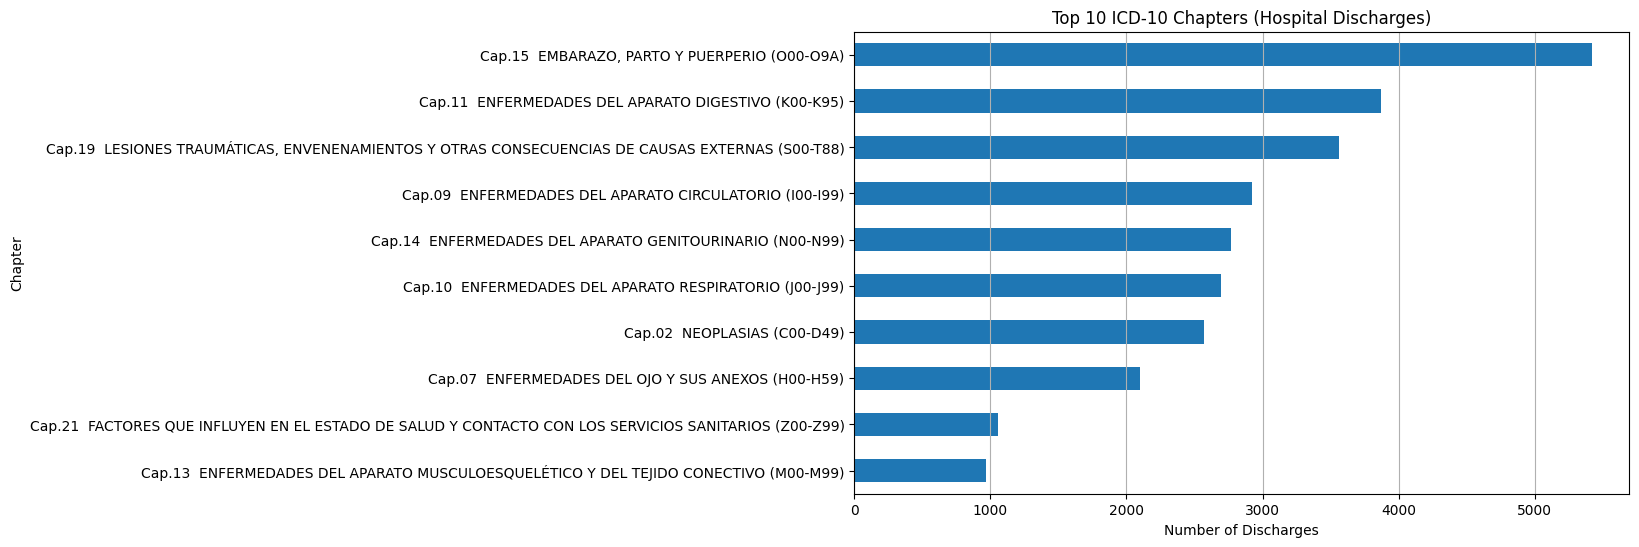

In [17]:
# ======================
# B.1.1 Top diagnostic chapters
# ======================

import matplotlib.pyplot as plt

# Contar por capítulo
chapters = (
    grd_com["Capítulo"]
    .value_counts()
    .head(10)
    .sort_values()
)

print("Top 10 diagnostic chapters:")
print(chapters)

# Plot
plt.figure(figsize=(10, 6))
chapters.plot(kind="barh")

plt.title("Top 10 ICD-10 Chapters (Hospital Discharges)")
plt.xlabel("Number of Discharges")
plt.ylabel("Chapter")

plt.grid(axis='x')

plt.show()

En las comunas estudiadas, las categorias de enfermades con mayores observaciones estan: enfermedades del aparato digestivo, del aparato circulatorio, del aparato genitourinario.

Top 15 specific diagnoses:
Descripción
Infección de vías urinarias, sitio no especificado                         220
Desgarro perineal de primer grado durante el parto                         220
Infarto subendocárdico agudo del miocardio                                 221
Cálculo de la vesícula biliar con colecistitis aguda                       226
Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas     253
Atención materna por cicatriz uterina debida a cirugía previa              266
COVID-19, virus identificado                                               270
Parto único espontáneo, presentación cefálica de vértice                   279
Neumonía, no especificada                                                  285
Fractura del cuello de fémur, cerrada                                      291
Nefritis tubulointersticial aguda                                          309
Apendicitis aguda, otra y no especificada                                  478
Cálculo de la

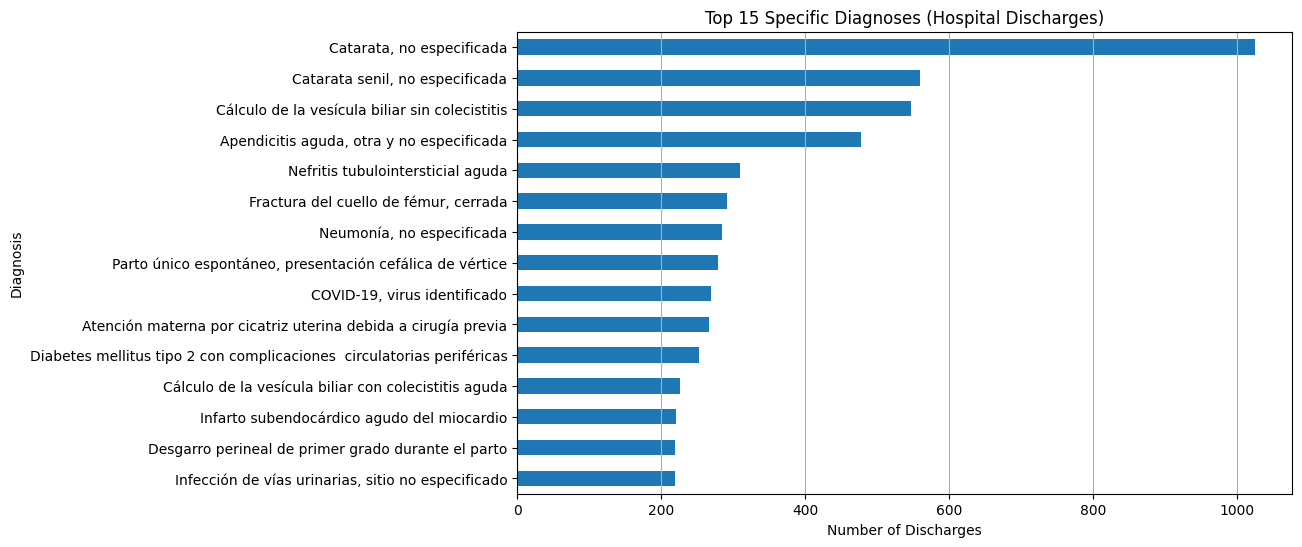

In [18]:
# ======================
# B.1.2 Top specific diagnoses
# ======================

import matplotlib.pyplot as plt

# Top 15 diagnósticos específicos
top_diag = (
    grd_com["Descripción"]
    .value_counts()
    .head(15)
    .sort_values()
)

print("Top 15 specific diagnoses:")
print(top_diag)

# Plot
plt.figure(figsize=(10, 6))
top_diag.plot(kind="barh")

plt.title("Top 15 Specific Diagnoses (Hospital Discharges)")
plt.xlabel("Number of Discharges")
plt.ylabel("Diagnosis")

plt.grid(axis='x')

plt.show()

Shares by nationality (top 5 chapters):
nat_group                                            Chilean   Foreign
Capítulo                                                              
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (...  0.931601  0.068399
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00...  0.863155  0.136845
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO...  0.874368  0.125632
Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A)       0.519823  0.480177
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y...  0.872615  0.127385


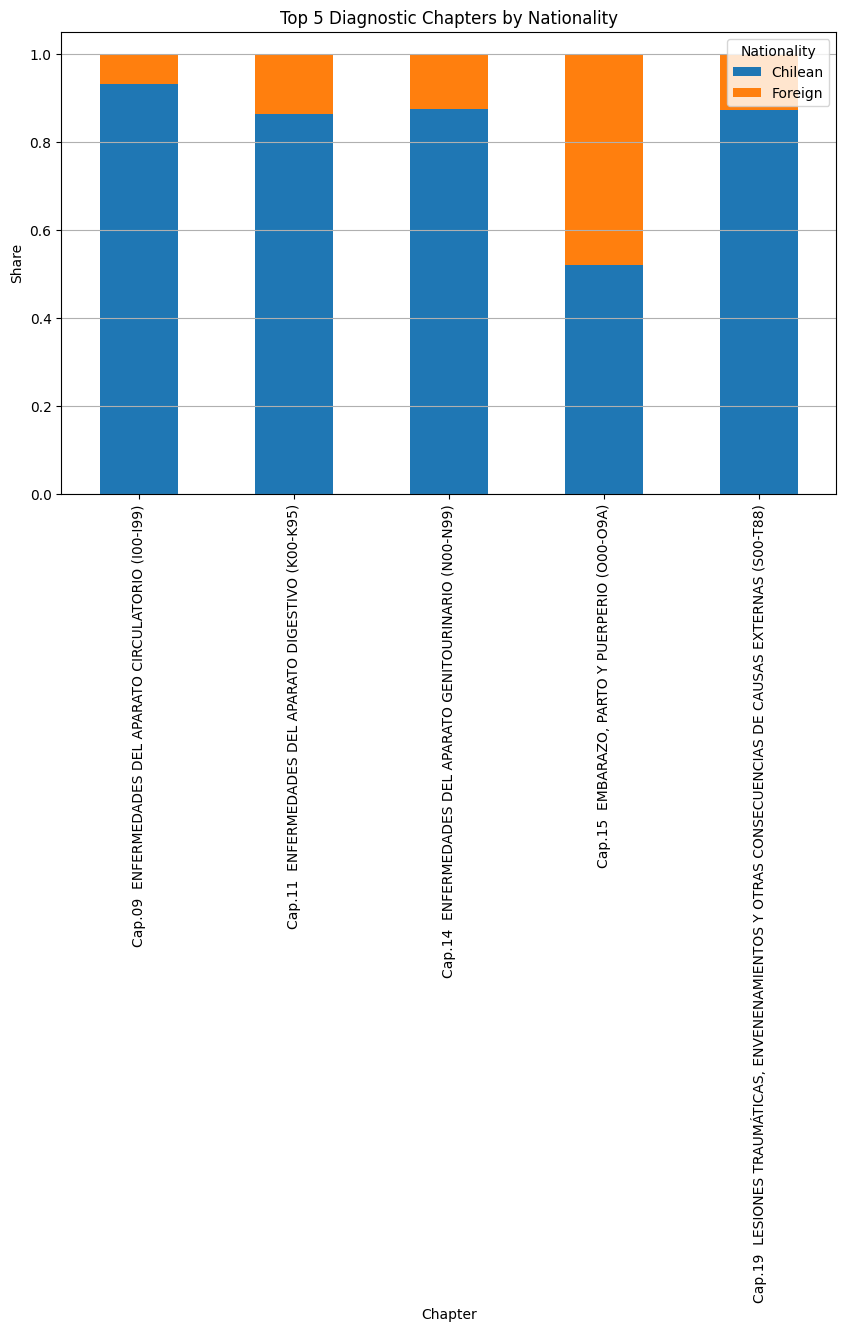

In [58]:
# ======================
# B.1.3 Diagnostic chapters by nationality
# ======================

import matplotlib.pyplot as plt

# Top 5 capítulos
top5_chapters = grd_com["Capítulo"].value_counts().head(5).index

# Filtrar
grd_top5 = grd_com[grd_com["Capítulo"].isin(top5_chapters)]

# Agrupar
chap_nat = (
    grd_top5
    .groupby(["Capítulo", "nat_group"])
    .size()
    .reset_index(name="count")
)

# Pivotear
chap_pivot = chap_nat.pivot(
    index="Capítulo",
    columns="nat_group",
    values="count"
).fillna(0)

# Convertir a proporciones
chap_share = chap_pivot.div(chap_pivot.sum(axis=1), axis=0)

print("Shares by nationality (top 5 chapters):")
print(chap_share)

# Plot
chap_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Top 5 Diagnostic Chapters by Nationality")
plt.ylabel("Share")
plt.xlabel("Chapter")
plt.legend(title="Nationality")

plt.grid(axis='y')

plt.show()

Al revisar el top 5 diagnosticos, aquel que llama mas la atencion es el de embarazos, ya que si bien los extranjeros corresponden un 16% del total estudiado, en esta categoría corresponden a un 50%

Length of stay (mean & median) by nationality:
               mean  median
nat_group                  
Chilean    6.652449     3.0
Foreign    4.675209     3.0




<Figure size 800x500 with 0 Axes>

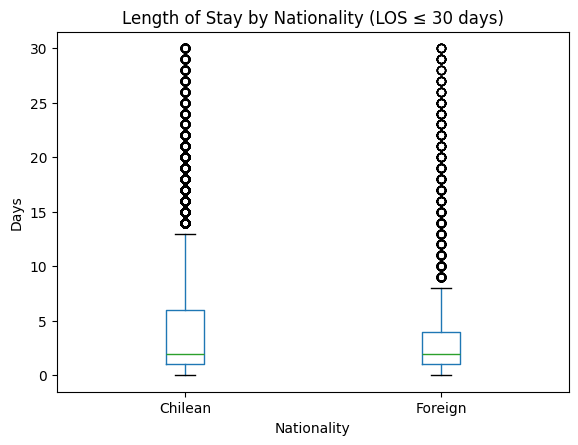

In [20]:
# ======================
# B.2.1 Length of stay by nationality
# ======================

import matplotlib.pyplot as plt

# Tabla resumen
los_stats = (
    grd_com
    .groupby("nat_group")["los"]
    .agg(["mean", "median"])
)

print("Length of stay (mean & median) by nationality:")
print(los_stats)

print("\n" + "=" * 80 + "\n")

# Filtrar LOS <= 30 para visualización
grd_los_plot = grd_com[grd_com["los"] <= 30]

# Boxplot
plt.figure(figsize=(8, 5))

grd_los_plot.boxplot(column="los", by="nat_group")

plt.title("Length of Stay by Nationality (LOS ≤ 30 days)")
plt.suptitle("")  # quita título automático
plt.xlabel("Nationality")
plt.ylabel("Days")

plt.grid()

plt.show()

Si bien las medianas son iguales, la media de los chilenos es mayor, al igual que sus rango tipicos, lo que significa a que los chilenos se quedan mas tiempo hospitalizados por lo general

Severity distribution:
nat_group           Chilean  Foreign
IR_29301_SEVERIDAD                  
0                      5548      586
1                      9095     2898
2                      5927     1035
3                      6649      749


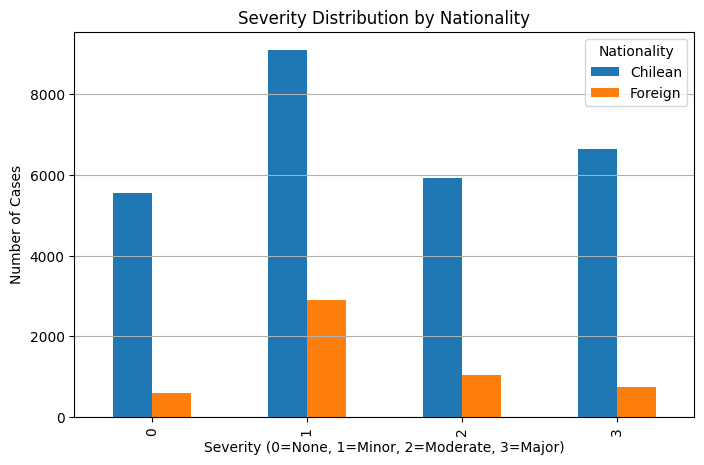

In [21]:
# ======================
# B.2.2 Severity distribution
# ======================

import matplotlib.pyplot as plt

# Convertir severidad a numérico
grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(
    grd_com["IR_29301_SEVERIDAD"],
    errors="coerce"
)

# Agrupar
severity = (
    grd_com
    .groupby(["IR_29301_SEVERIDAD", "nat_group"])
    .size()
    .reset_index(name="count")
)

# Pivotear
severity_pivot = severity.pivot(
    index="IR_29301_SEVERIDAD",
    columns="nat_group",
    values="count"
).fillna(0)

print("Severity distribution:")
print(severity_pivot)

# Plot
severity_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Severity Distribution by Nationality")
plt.xlabel("Severity (0=None, 1=Minor, 2=Moderate, 3=Major)")
plt.ylabel("Number of Cases")
plt.legend(title="Nationality")

plt.grid(axis='y')

plt.show()

In [22]:
# ======================
# B.2.3 Discharge type and mortality
# ======================

import pandas as pd

# Distribución de TIPOALTA
alta_dist = (
    grd_com
    .groupby(["TIPOALTA", "nat_group"])
    .size()
    .reset_index(name="count")
)

print("Distribution of discharge types:")
print(alta_dist)

print("\n" + "=" * 80 + "\n")

# Calcular mortalidad (FALLECIDO)
mortality = (
    grd_com
    .assign(is_dead=lambda x: x["TIPOALTA"] == "FALLECIDO")
    .groupby("nat_group")["is_dead"]
    .mean()
)

print("In-hospital mortality rate:")
print(mortality)

Distribution of discharge types:
                                         TIPOALTA nat_group  count
0                                 ALTA VOLUNTARIA   Chilean    303
1                                 ALTA VOLUNTARIA   Foreign     70
2    DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE   Chilean     92
3    DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE   Foreign      1
4   DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS   Chilean     58
5   DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS   Foreign     16
6           DERIVACIÓN INST. PRIVADA (VOLUNTARIO)   Chilean     13
7           DERIVACIÓN INST. PRIVADA (VOLUNTARIO)   Foreign      1
8     DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL   Chilean    131
9     DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL   Foreign     19
10          DERIVACIÓN OTRO HOSPITAL DEL SERVICIO   Chilean    145
11          DERIVACIÓN OTRO HOSPITAL DEL SERVICIO   Foreign     32
12                                      DOMICILIO   Chilean  24339
13                           

In [45]:
!pip install contextily

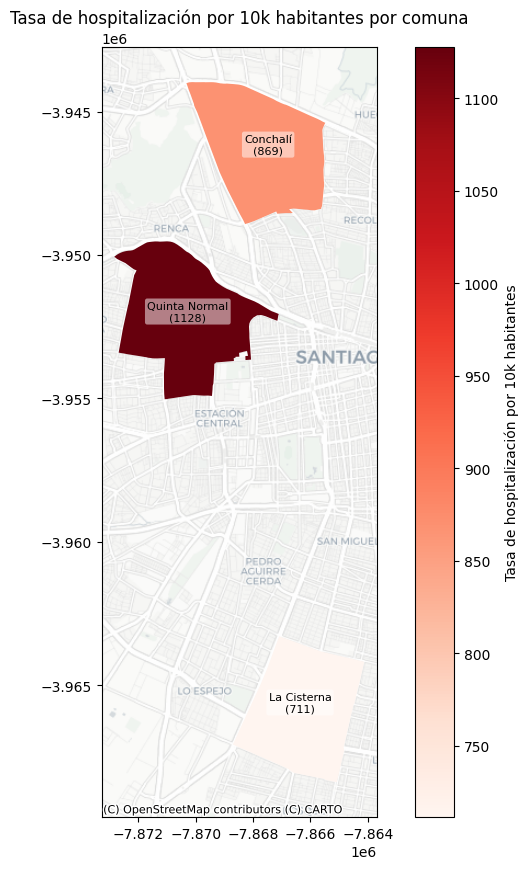

In [49]:
# ======================
# B.3 Spatial View
# ======================
import os
import pandas as pd

# Rutas
RUTA_TAREA1 = "/content/drive/MyDrive/Tarea1_Censo/output/tarea1_comuna_summary.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Preparación de datos /output"
OUTPUT_GRD = f"{OUTPUT_DIR}/tarea2_grd_summary.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar población
t1 = pd.read_csv(RUTA_TAREA1)
t1["codigo_comuna"] = t1["codigo_comuna"].astype(str)

# Mapear comunas
comuna_name_to_code = {
    "CONCHALÍ": "13104",
    "LA CISTERNA": "13109",
    "QUINTA NORMAL": "13126"
}

gr_com_copy = grd_com.copy()
gr_com_copy["codigo_comuna"] = gr_com_copy["COMUNA"].map(comuna_name_to_code)
# ======================
# Agregaciones principales
# ======================

summary = (
    gr_com_copy
    .groupby("codigo_comuna")
    .agg(
        grd_total=("COMUNA", "size"),
        grd_chilean=("nat_group", lambda x: (x == "Chilean").sum()),
        grd_foreign=("nat_group", lambda x: (x == "Foreign").sum()),
        grd_mean_los=("los", "mean"),
        grd_mean_los_chilean=("los", lambda x: x[gr_com_copy.loc[x.index, "nat_group"] == "Chilean"].mean()),
        grd_mean_los_foreign=("los", lambda x: x[gr_com_copy.loc[x.index, "nat_group"] == "Foreign"].mean()),
        grd_mean_severity=("IR_29301_SEVERIDAD", lambda x: pd.to_numeric(x, errors="coerce").mean())
    )
    .reset_index()
)
# % extranjeros
summary["grd_pct_foreign"] = summary["grd_foreign"] / summary["grd_total"]


summary = summary.merge(mortality, on="codigo_comuna", how="left")

# Top 3 capítulos
top3_chapters = (
    gr_com_copy
    .groupby("codigo_comuna")["Capítulo"]
    .apply(lambda x: ", ".join(x.value_counts().head(3).index))
    .reset_index(name="grd_top3_chapters")
)

summary = summary.merge(top3_chapters, on="codigo_comuna", how="left")

# Merge con población
summary = summary.merge(
    t1[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

# Tasa por 10k
summary["grd_rate_per_10k"] = (
    summary["grd_total"] / summary["pop_total"]
) * 10000

import geopandas as gpd

comunas_gdf = gpd.read_file("/content/drive/MyDrive/Preparación de datos/comunas.shp")
#Merge de nombre comuna y tasa por 10k con comunas gdf
comunas_gdf = comunas_gdf.merge(summary[["nombre_comuna", "grd_rate_per_10k"]], left_on="Comuna", right_on="nombre_comuna")

#graficar mapa con comunas y tasas
import matplotlib.pyplot as plt
import contextily as cx

fig, ax = plt.subplots(figsize=(10, 10))
comunas_gdf.plot(ax=ax, column="grd_rate_per_10k", cmap="Reds", legend=True, legend_kwds={'label': "Tasa de hospitalización por 10k habitantes"})

# Add comuna names and rates
comunas_gdf["coords"] = comunas_gdf["geometry"].apply(lambda x: x.representative_point().coords[:])
comunas_gdf["coords"] = [coords[0] for coords in comunas_gdf["coords"]]

for idx, row in comunas_gdf.iterrows():
    ax.annotate(
        text=f"{row['Comuna']}\n({row['grd_rate_per_10k']:.0f})", # Add rate below name
        xy=row["coords"],
        horizontalalignment="center",
        fontsize=8,
        color="black",
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )

# Change basemap
cx.add_basemap(ax, crs=comunas_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
ax.set_title("Tasa de hospitalización por 10k habitantes por comuna")
plt.show()

In [51]:
# ======================
# B.4 Comuna-Level GRD Summary Table
# ======================

# Reordenar columnas
summary = summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "grd_total",
        "grd_chilean",
        "grd_foreign",
        "grd_pct_foreign",
        "grd_mean_los",
        "grd_mean_los_chilean",
        "grd_mean_los_foreign",
        "grd_mean_severity",
        "grd_mortality_rate",
        "grd_top3_chapters",
        "grd_rate_per_10k"
    ]
]

print("\n" + "=" * 80 + "\n")

# Guardar CSV
summary.to_csv(OUTPUT_GRD, index=False)
print(f"Archivo guardado en: {OUTPUT_GRD}")
display(summary)




Archivo guardado en: /content/drive/MyDrive/Preparación de datos /output/tarea2_grd_summary.csv


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13104,Conchalí,10561,9346,1215,0.115046,6.366632,6.616413,4.445267,1.429505,0.036834,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",868.596149
1,13109,La Cisterna,7338,6249,1089,0.148406,6.360998,6.642663,4.744720,1.610793,0.037885,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",711.342905
2,13126,Quinta Normal,14588,11624,2964,0.203181,6.291952,6.686683,4.743927,1.452838,0.033178,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",1127.784091
